# Pre-fog exploration on detection model

In [1]:
import numpy as np
import pandas as pd


In [6]:
train_subjects = [2, 3, 10, 12, 13, 14, 16, 17, 18, 21]
val_subjects = [1, 5, 6, 7, 11, 15, 20]
test_subjects = [4, 8, 9, 19, 22]

In [25]:
def segment_data(df, subjects, w=2, o=0.75, fs=60):
    win_size = int(w * fs)
    step = int(win_size * (1 - o))
    
    # Order matters for the Multi-Branch CNN: 8 Ankle channels first, 4 Back channels last
    cols = [
        'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
        'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
        'back_q0', 'back_q1', 'back_q2', 'back_q3'
    ]
    
    X, y = [], []
    
    for sub in subjects:
        sub_df = df[df['subjectID'] == sub].reset_index(drop=True)
        data = sub_df[cols].values
        labels = sub_df['fog'].values
        
        for i in range(0, len(data) - win_size, step):
            window = data[i : i + win_size]
            # --- RELATIVE TRANSFORMATION ---
            # Subtract the first sample of the window from the whole window
            window_rel = window - window[0]
            
            X.append(window_rel)
            # Use the mode (most frequent) label for the window
            y.append(pd.Series(labels[i : i + win_size]).mode()[0])
            
    return np.array(X), np.array(y)

# Load your generated quaternions file
df_quat = pd.read_csv('sensor_data_quaternions.csv')

print("Segmenting datasets...")
X_train, y_train = segment_data(df_quat, train_subjects)
X_val, y_val     = segment_data(df_quat, val_subjects)
X_test, y_test   = segment_data(df_quat, test_subjects)

Segmenting datasets...


In [ ]:
# Check for NaN/Inf in training data
for inputs, labels in train_loader:
    if torch.isnan(inputs).any() or torch.isinf(inputs).any():
        print(" NaN/Inf found in inputs!")
        break
    if torch.isnan(labels).any() or torch.isinf(labels).any():
        print(" NaN/Inf found in labels!")
        break

print("✓ Data looks clean")

✓ Data looks clean


In [27]:
# Remove samples with NaN
valid_idx = ~(np.isnan(X_train).any(axis=(1, 2)) | np.isnan(y_train))
X_train = X_train[valid_idx]
y_train = y_train[valid_idx]

print(f"Removed {(~valid_idx).sum()} samples with NaN")

Removed 0 samples with NaN


In [28]:
import torch
from torch.utils.data import Dataset, DataLoader

class FogDataset(Dataset):
    def __init__(self, X, y):
        # Convert to float32 and move to tensors
        # X shape from segmentation: (Samples, Time, Channels) -> e.g., (N, 120, 12)
        # PyTorch Conv1d expects: (Samples, Channels, Time) -> e.g., (N, 12, 120)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# --- Usage ---
# Assuming you already have X_train, y_train, etc., from your segmentation script
train_dataset = FogDataset(X_train, y_train)
val_dataset = FogDataset(X_val, y_val)
test_dataset = FogDataset(X_test, y_test)

# DataLoader handles batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiBranchCNN(nn.Module):
    def __init__(self):
        super(MultiBranchCNN, self).__init__()
        
        # Branch 1: Ankles (8 channels: Left q0-q3 + Right q0-q3)
        self.ankle_branch = nn.Sequential(
            nn.Conv1d(8, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Reduces to a single vector
        )
        
        # Branch 2: Back (4 channels: Back q0-q3)
        self.back_branch = nn.Sequential(
            nn.Conv1d(4, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            nn.Conv1d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        # Fusion Layer: Combines 128 (Ankles) + 64 (Back) = 192 features
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.32),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x is assumed to be (Batch, Channels, Time) -> (Batch, 12, 120)
        ankles = x[:, 0:8, :] # First 8 channels
        back = x[:, 8:12, :]  # Last 4 channels
        
        feat_ankles = self.ankle_branch(ankles).view(x.size(0), -1)
        feat_back = self.back_branch(back).view(x.size(0), -1)
        
        # Concatenate branches
        combined = torch.cat((feat_ankles, feat_back), dim=1)
        return self.classifier(combined)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MultiBranchCNN().to(device)
print(f"Model initialized on: {device}")

Model initialized on: cpu


In [30]:
import numpy as np

def train_model(model, train_loader, val_loader, epochs=50, lr=0.008):
    # Setup Optimizer and Loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0036)
    #criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    criterion = nn.BCELoss()
    #criterion = FocalLoss(alpha=0.75, gamma=2.0)

    # Scheduler: Reduces LR if validation loss doesn't improve for 5 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_losses = []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze(-1)
                v_loss = criterion(outputs, labels)
                val_losses.append(v_loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        
        # Update Scheduler
        scheduler.step(avg_val_loss)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'test_fog_exploration.pth')
            print("--> Model Saved!")

# --- START TRAINING ---
train_model(model, train_loader, val_loader)

Epoch 1/50 | Train Loss: 0.3970 | Val Loss: 0.5733 | LR: 0.008000
--> Model Saved!
Epoch 2/50 | Train Loss: 0.3315 | Val Loss: 0.4103 | LR: 0.008000
--> Model Saved!
Epoch 3/50 | Train Loss: 0.3150 | Val Loss: 0.3886 | LR: 0.008000
--> Model Saved!
Epoch 4/50 | Train Loss: 0.3231 | Val Loss: 0.3477 | LR: 0.008000
--> Model Saved!
Epoch 5/50 | Train Loss: 0.2991 | Val Loss: 0.3435 | LR: 0.008000
--> Model Saved!
Epoch 6/50 | Train Loss: 0.3006 | Val Loss: 0.3393 | LR: 0.008000
--> Model Saved!
Epoch 7/50 | Train Loss: 0.2968 | Val Loss: 0.3474 | LR: 0.008000
Epoch 8/50 | Train Loss: 0.2819 | Val Loss: 0.3790 | LR: 0.008000
Epoch 9/50 | Train Loss: 0.2848 | Val Loss: 0.3250 | LR: 0.008000
--> Model Saved!
Epoch 10/50 | Train Loss: 0.2903 | Val Loss: 0.3192 | LR: 0.008000
--> Model Saved!
Epoch 11/50 | Train Loss: 0.2771 | Val Loss: 0.3214 | LR: 0.008000
Epoch 12/50 | Train Loss: 0.2842 | Val Loss: 0.3420 | LR: 0.008000
Epoch 13/50 | Train Loss: 0.2821 | Val Loss: 0.3330 | LR: 0.008000
Ep

In [43]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, test_loader, device, threshold=0.7):
    """
    Evaluates the model on the test set and returns true labels, predictions, and probabilities.
    This version is corrected to handle single-item batches.
    """
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():  # No gradients needed for evaluation
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            
            # Get model output
            outputs = model(inputs).squeeze()
            
            # --- CORRECTION FOR SINGLE-ITEM BATCH ---
            # If the batch has only one sample, 'outputs' becomes a 0-D tensor (scalar).
            # We need to handle it differently from a 1-D tensor (vector).
            if outputs.dim() == 0:
                # It's a single number, so we append it directly
                all_probs.append(outputs.cpu().item())
                pred = (outputs > threshold).float()
                all_preds.append(pred.cpu().item())
            else:
                # It's a vector for a multi-item batch, so we use extend
                all_probs.extend(outputs.cpu().numpy())
                preds = (outputs > threshold).float()
                all_preds.extend(preds.cpu().numpy())
            
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# --- EXECUTION ---
# Load the best weights saved during training
# Make sure the model is already defined in a previous cell
# Evaluate the model with the corrected function
y_true, y_pred, y_probs = evaluate_model(model, test_loader, device, threshold=0.43)

print("Evaluation completed successfully.")
print(f"y_true length: {len(y_true)}")
print(f"y_pred length: {len(y_pred)}")
print(f"y_probs length: {len(y_probs)}")

Evaluation completed successfully.
y_true length: 2049
y_pred length: 2049
y_probs length: 2049


In [44]:
print("\n" + "="*30)
print("   FINAL TEST RESULTS")
print("="*30)

# 1. Classification Report
print(classification_report(y_true, y_pred, target_names=['Normal', 'FoG']))

# 2. AUC Score (measures how well the model separates the two classes)
auc = roc_auc_score(y_true, y_probs)
print(f"Test AUC-ROC: {auc:.4f}")

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)


   FINAL TEST RESULTS
              precision    recall  f1-score   support

      Normal       0.90      0.92      0.91      1651
         FoG       0.64      0.59      0.61       398

    accuracy                           0.86      2049
   macro avg       0.77      0.75      0.76      2049
weighted avg       0.85      0.86      0.85      2049

Test AUC-ROC: 0.8958

Confusion Matrix:
[[1522  129]
 [ 164  234]]


In [34]:
def get_true_and_probabilities(model, data_loader, device):
    """
    Collects true labels and predicted probabilities from a data loader.

    Args:
        model (torch.nn.Module): The trained model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the dataset (e.g., validation or test).
        device (torch.device): The device to run the model on.

    Returns:
        y_true (np.array): True labels.
        y_prob (np.array): Predicted probabilities.
    """
    model.eval()  # Set model to evaluation mode
    y_true = []
    y_prob = []

    with torch.no_grad():  # No gradients needed for evaluation
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs).squeeze()  # Get model predictions
            
            # Collect true labels and probabilities
            y_true.extend(labels.numpy())
            y_prob.extend(outputs.cpu().numpy())

    return np.array(y_true), np.array(y_prob)

# Example usage:
y_val_true, y_val_prob = get_true_and_probabilities(model, val_loader, device)

In [35]:
import numpy as np
from sklearn.metrics import f1_score

def find_best_threshold(y_true, y_prob, thresholds=None):
    """
    Finds the best threshold for classification based on F1-score.

    Args:
        y_true (np.array): True binary labels.
        y_prob (np.array): Predicted probabilities.
        thresholds (list or np.array): List of thresholds to evaluate. Defaults to np.linspace(0.1, 0.9, 33).

    Returns:
        best_threshold (float): The threshold that maximizes the F1-score.
        best_f1 (float): The highest F1-score achieved.
    """
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 33)
    
    best_threshold = 0.0
    best_f1 = -1.0
    
    for thr in thresholds:
        y_pred = (y_prob > thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thr
    
    return best_threshold, best_f1

# Example usage:
# Assuming y_val_true and y_val_prob are your true labels and predicted probabilities for the validation set
best_thr, best_f1 = find_best_threshold(y_val_true, y_val_prob)
print(f"Best Threshold: {best_thr:.2f}, Best F1-Score: {best_f1:.4f}")

Best Threshold: 0.38, Best F1-Score: 0.6355


# Pre-FoG Signal Exploration

This section explores whether model probabilities increase *before* FoG onset.

## Step 1: Identify FoG Onsets

Find all the places where FoG starts (0 → 1 transition)

In [45]:
# Find where FoG starts (0 → 1 transition)
onsets = np.where((y_true[:-1] == 0) & (y_true[1:] == 1))[0] + 1
# This finds indices where y_true changes from 0 to 1

print(f"\nFound {len(onsets)} FoG onset events")
if len(onsets) > 0:
    print(f"Example onsets (first 10): {onsets[:10]}")
else:
    print("WARNING: No FoG onsets found. Check your data.")


Found 21 FoG onset events
Example onsets (first 10): [ 516  769  795  839  867  946  975 1010 1071 1105]


## Step 2: Extract Pre-FoG Trajectories

For each FoG onset, look back N windows and collect the probabilities

In [38]:
lookback_window = 10  # How many windows to look back before FoG
all_trajectories = []  # Store all pre-FoG probability sequences
valid_onsets = []  # Onsets with enough history

for onset_idx in onsets:
    if onset_idx >= lookback_window:  # Ensure we have enough history
        trajectory = y_probs[onset_idx - lookback_window : onset_idx + 1]
        all_trajectories.append(trajectory)
        valid_onsets.append(onset_idx)

all_trajectories = np.array(all_trajectories)
print(f"\nValid onsets (with {lookback_window} windows of history): {len(valid_onsets)}")
if len(all_trajectories) > 0:
    print(f"Trajectory shape: {all_trajectories.shape}")  # (n_onsets, lookback_window + 1)
else:
    print("WARNING: No valid trajectories. Either no onsets or not enough history.")


Valid onsets (with 10 windows of history): 21
Trajectory shape: (21, 11)


## Step 3: Visualize Trajectories

Show individual trajectories, mean trend, and statistics

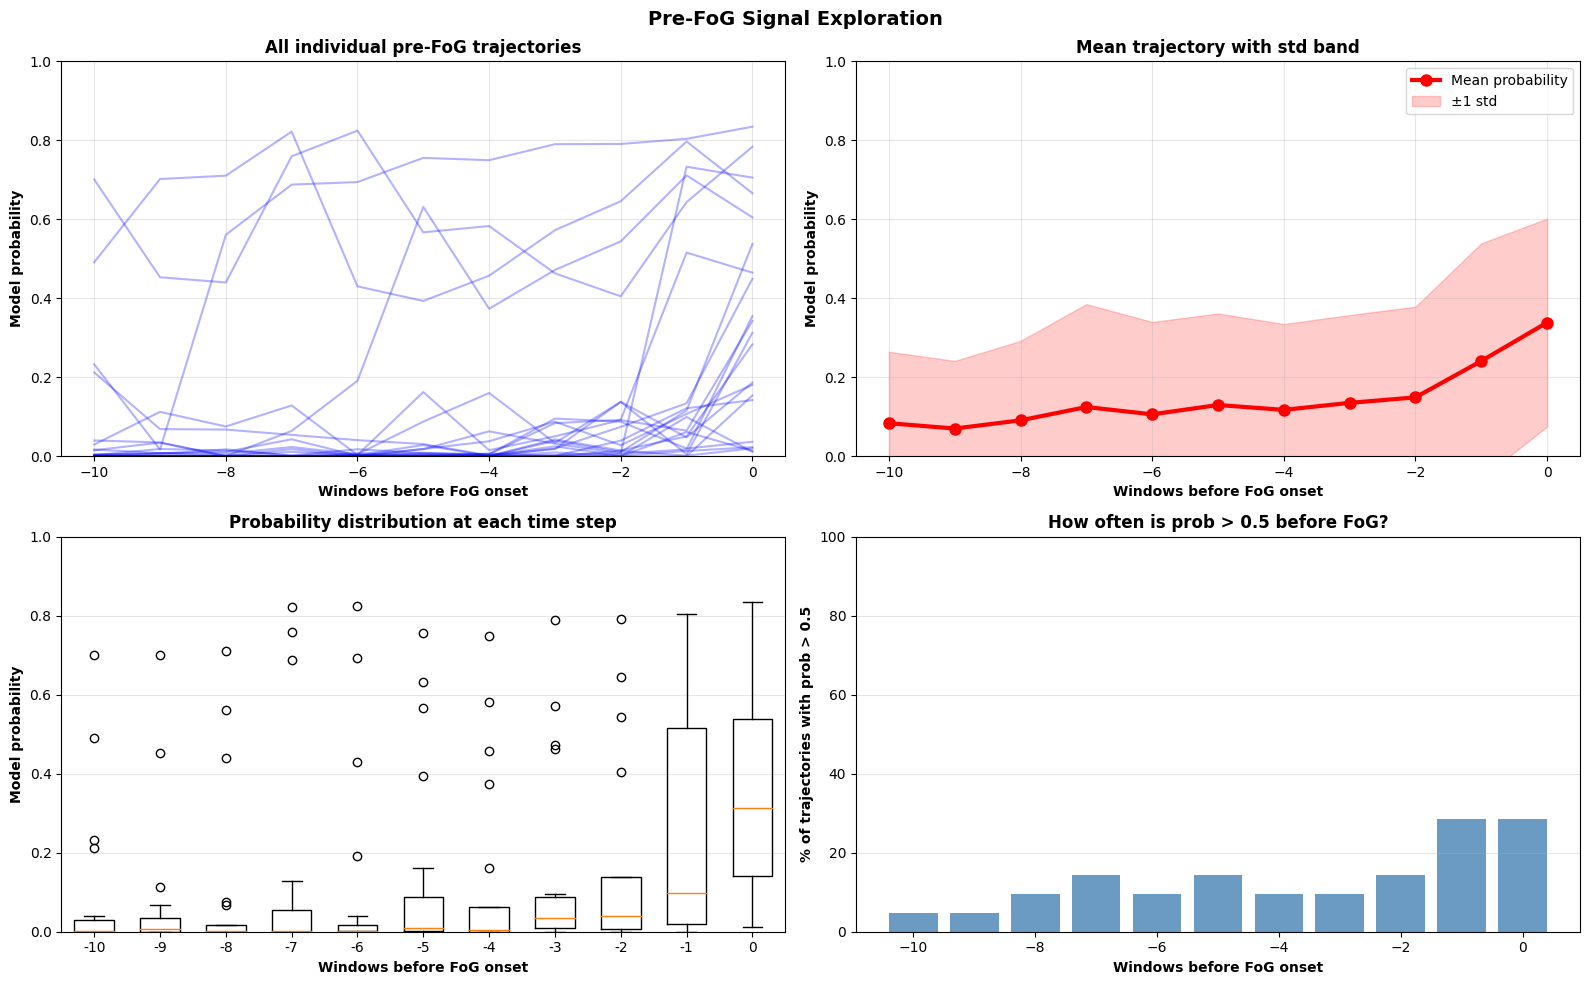

In [39]:
if len(all_trajectories) == 0:
    print("Cannot visualize: no valid trajectories")
else:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 3a. Individual trajectories (all lines)
    ax = axes[0, 0]
    for traj in all_trajectories:
        ax.plot(range(-lookback_window, 1), traj, alpha=0.3, color='blue')
    ax.set_xlabel('Windows before FoG onset', fontweight='bold')
    ax.set_ylabel('Model probability', fontweight='bold')
    ax.set_title('All individual pre-FoG trajectories', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

    # 3b. Mean trajectory with std band
    ax = axes[0, 1]
    mean_traj = np.mean(all_trajectories, axis=0)
    std_traj = np.std(all_trajectories, axis=0)
    x_pos = np.arange(-lookback_window, 1)
    ax.plot(x_pos, mean_traj, 'o-', linewidth=3, label='Mean probability', color='red', markersize=8)
    ax.fill_between(x_pos, mean_traj - std_traj, mean_traj + std_traj, alpha=0.2, color='red', label='±1 std')
    ax.set_xlabel('Windows before FoG onset', fontweight='bold')
    ax.set_ylabel('Model probability', fontweight='bold')
    ax.set_title('Mean trajectory with std band', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1])

    # 3c. Box plot: probability distribution at each relative position
    ax = axes[1, 0]
    data_for_boxplot = [all_trajectories[:, i] for i in range(all_trajectories.shape[1])]
    positions = np.arange(-lookback_window, 1)
    ax.boxplot(data_for_boxplot, positions=positions, widths=0.6)
    ax.set_xlabel('Windows before FoG onset', fontweight='bold')
    ax.set_ylabel('Model probability', fontweight='bold')
    ax.set_title('Probability distribution at each time step', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim([0, 1])

    # 3d. Histogram: how many trajectories have prob > 0.5 at each step
    ax = axes[1, 1]
    high_prob_counts = np.sum(all_trajectories > 0.5, axis=0)
    high_prob_pct = (high_prob_counts / len(all_trajectories)) * 100
    ax.bar(np.arange(-lookback_window, 1), high_prob_pct, color='steelblue', alpha=0.8)
    ax.set_xlabel('Windows before FoG onset', fontweight='bold')
    ax.set_ylabel('% of trajectories with prob > 0.5', fontweight='bold')
    ax.set_title('How often is prob > 0.5 before FoG?', fontweight='bold')
    ax.set_ylim([0, 100])
    ax.grid(alpha=0.3, axis='y')

    plt.suptitle('Pre-FoG Signal Exploration', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Step 4: Quantify the Trend

Calculate statistics at each time step before FoG onset

In [40]:
if len(all_trajectories) == 0:
    print("Cannot compute statistics: no valid trajectories")
else:
    stats_data = []
    for i in range(all_trajectories.shape[1]):
        pos = i - lookback_window
        probs_at_pos = all_trajectories[:, i]
        stats_data.append({
            'relative_window': pos,
            'mean_prob': np.mean(probs_at_pos),
            'median_prob': np.median(probs_at_pos),
            'std_prob': np.std(probs_at_pos),
            'min_prob': np.min(probs_at_pos),
            'max_prob': np.max(probs_at_pos),
            'pct_above_05': (np.sum(probs_at_pos > 0.5) / len(probs_at_pos)) * 100,
        })

    stats_df = pd.DataFrame(stats_data)
    print("\nStatistics by relative position (windows before FoG onset):")
    print(stats_df.to_string(index=False))
    
    # Check if mean probability increases towards FoG
    mean_early = stats_df.iloc[0]['mean_prob']  # -10 windows
    mean_late = stats_df.iloc[-1]['mean_prob']   # 0 (FoG onset)
    increase = mean_late - mean_early
    
    print("\n" + "="*80)
    print("💡 IS THERE A TREND?")
    print("="*80)
    print(f"Mean prob at -{lookback_window} windows: {mean_early:.4f}")
    print(f"Mean prob at FoG onset (0): {mean_late:.4f}")
    print(f"Increase: {increase:.4f}")
    if increase > 0.05:
        print("\n✓ YES: Probabilities tend to increase before FoG")
        print("  → You can likely build a predictor with LSTM or similar")
    else:
        print("\n✗ NO or WEAK: No clear upward trend detected")
        print("  → Signal may be too weak for simple prediction")


Statistics by relative position (windows before FoG onset):
 relative_window  mean_prob  median_prob  std_prob     min_prob  max_prob  pct_above_05
             -10   0.083614     0.002739  0.181011 3.844532e-06  0.700950      4.761905
              -9   0.070132     0.007462  0.171192 2.000384e-06  0.701947      4.761905
              -8   0.090847     0.000818  0.201228 9.850572e-06  0.710477      9.523810
              -7   0.124579     0.002045  0.260597 6.743444e-07  0.821988     14.285714
              -6   0.106047     0.002636  0.233952 1.156001e-05  0.824530      9.523810
              -5   0.129709     0.008852  0.231871 1.417310e-05  0.755550     14.285714
              -4   0.117311     0.005163  0.217411 7.101347e-06  0.749672      9.523810
              -3   0.135158     0.033583  0.222394 9.543348e-05  0.790180      9.523810
              -2   0.148994     0.039424  0.229610 6.939996e-05  0.790811     14.285714
              -1   0.241097     0.099239  0.298022 1.777912

## Step 5: Quick Heuristic Baseline

Test a simple rule: "If prob > threshold at t-1, predict FoG at t"

In [41]:
print("\n" + "="*80)
print("SIMPLE HEURISTIC BASELINE")
print("="*80)

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
print("\nRule: 'If prob > threshold at window t-1, predict FoG at window t'\n")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 48)

for thr in thresholds_to_test:
    pred_temp = np.zeros_like(y_true)
    for i in range(1, len(y_true)):
        if y_probs[i-1] > thr:
            pred_temp[i] = 1
    
    prec = precision_score(y_true[1:], pred_temp[1:], zero_division=0)
    rec = recall_score(y_true[1:], pred_temp[1:], zero_division=0)
    f1 = f1_score(y_true[1:], pred_temp[1:], zero_division=0)
    
    print(f"{thr:<12.1f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("\nIf even these simple heuristics show reasonable F1 (>0.6):")
print("  → There is predictive signal in the probabilities")
print("\nIf all F1-scores are poor (<0.3):")
print("  → The signal is too weak; need better feature engineering")


SIMPLE HEURISTIC BASELINE

Rule: 'If prob > threshold at window t-1, predict FoG at window t'

Threshold    Precision    Recall       F1-Score    
------------------------------------------------
0.3          0.4685       0.8216       0.5967      
0.4          0.6269       0.6332       0.6300      
0.5          0.6623       0.5075       0.5747      
0.6          0.6920       0.3894       0.4984      
0.7          0.7338       0.2839       0.4094      

If even these simple heuristics show reasonable F1 (>0.6):
  → There is predictive signal in the probabilities

If all F1-scores are poor (<0.3):
  → The signal is too weak; need better feature engineering


In [ ]:
def segment_data_with_prefog_labels(df, subjects, w=1, o=0.75, fs=60,
                                     prefog_window_sec=2,
                                     quat_cols=None):
    """
    Segment data into windows with 3-class labels using MODE (most common label).
    - 0: Normal
    - 1: Pre-FoG
    - 2: FoG
    """

    if quat_cols is None:
        quat_cols = [
            'ankleL_q0', 'ankleL_q1', 'ankleL_q2', 'ankleL_q3',
            'ankleR_q0', 'ankleR_q1', 'ankleR_q2', 'ankleR_q3',
            'back_q0', 'back_q1', 'back_q2', 'back_q3'
        ]

    w_samples = int(w * fs)
    step = int(w_samples * (1 - o))
    prefog_samples = int(prefog_window_sec * fs)

    X, y_fog = [], []

    for subject in subjects:
        subject_data = df[df['subjectID'] == subject].reset_index(drop=True)
        
        if len(subject_data) < w_samples:
            continue

        fog_col = subject_data['fog'].values

        for start in range(0, len(subject_data) - w_samples + 1, step):
            end = start + w_samples
            window_data = subject_data.iloc[start:end]

            window_quat = window_data[quat_cols].values
            if np.isnan(window_quat).any():
                continue

            window_quat = window_quat - window_quat[0]
            X.append(window_quat)

            # Get MODE of current window labels
            current_fog_mode = pd.Series(fog_col[start:end]).mode()[0]

            # Check future for FoG
            future_end = min(end + prefog_samples, len(fog_col))
            future_fog = np.max(fog_col[end:future_end]) if future_end > end else 0

            # Assign 3-class label
            if current_fog_mode == 1:
                label = 2  # FoG
            elif future_fog == 1:
                label = 1  # Pre-FoG
            else:
                label = 0  # Normal

            y_fog.append(label)

    return np.array(X), np.array(y_fog)

In [ ]:
print("\n" + "-"*80)
print("Creating 3-class labels for test set...")
print("-"*80)

test_subjects = [4, 8, 9, 19, 22] 

X_test_new, y_test_new = segment_data_with_prefog_labels(
    df_quat,  # Your dataframe
    test_subjects,
    prefog_window_sec=1
)

print(f"\n✓ Test set relabeled:")
print(f"  Total windows: {len(X_test_new)}")
print(f"  Normal (0): {np.sum(y_test_new == 0)}")
print(f"  Pre-FoG (1): {np.sum(y_test_new == 1)}")
print(f"  FoG (2): {np.sum(y_test_new == 2)}")

X_train_new, y_train_new = segment_data_with_prefog_labels(
    df_quat,
    train_subjects,
    prefog_window_sec=1 # Keep same prefog window for consistency
)

X_val_new, y_val_new = segment_data_with_prefog_labels(
    df_quat,
    val_subjects,
    prefog_window_sec=1
)

In [ ]:
model.load_state_dict(torch.load('test_fog_exploration_1s.pth'))
model.eval()

In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)
with torch.no_grad():
    y_probs_test = model(X_test_tensor).squeeze().cpu().numpy()

In [ ]:
print("\n" + "-"*80)
print("VALIDATION: Detection model on FoG-RELATED windows (Pre-FoG + FoG combined)")
print("-"*80)

# Create binary labels: FoG-related (1) vs Normal (0)
y_test_fog_related_binary = ((y_test_new == 1) | (y_test_new == 2)).astype(int)

print(f"\nClass distribution:")
print(f"  Normal (0): {np.sum(y_test_fog_related_binary == 0)}")
print(f"  FoG-related (1): {np.sum(y_test_fog_related_binary == 1)}")
print(f"    └─ Pre-FoG: {np.sum(y_test_new == 1)}")
print(f"    └─ FoG: {np.sum(y_test_new == 2)}")

# Test different thresholds
print("\nThreshold analysis:")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 48)

from sklearn.metrics import precision_score, recall_score, f1_score

best_f1 = 0
best_thr = 0

for thr in np.arange(0.2, 0.8, 0.1):
    pred_fog_related = (y_probs_test > thr).astype(int)

    prec = precision_score(y_test_fog_related_binary, pred_fog_related, zero_division=0)
    rec = recall_score(y_test_fog_related_binary, pred_fog_related, zero_division=0)
    f1 = f1_score(y_test_fog_related_binary, pred_fog_related, zero_division=0)

    print(f"{thr:<12.1f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

print(f"\n✓ Best threshold: {best_thr:.1f} with F1={best_f1:.4f}")

# Detailed report
print("\n" + "-"*80)
print(f"CLASSIFICATION REPORT (threshold {best_thr:.1f})")
print("-"*80)

pred_fog_related_best = (y_probs_test > best_thr).astype(int)
print(classification_report(y_test_fog_related_binary, pred_fog_related_best,
                           target_names=['Normal', 'FoG-Related (Pre-FoG + FoG)']))

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"""
- Precision: {precision_score(y_test_fog_related_binary, pred_fog_related_best, zero_division=0):.4f}
- Recall: {recall_score(y_test_fog_related_binary, pred_fog_related_best, zero_division=0):.4f}  
- F1-Score: {f1_score(y_test_fog_related_binary, pred_fog_related_best, zero_division=0):.4f}
""")

In [ ]:
chosen_threshold = 0.3
pred = (y_probs_test > chosen_threshold).astype(int)

print("WINDOW-LEVEL ACCURACY")
print("─"*50)

TP = np.sum((pred == 1) & is_prefog)
TN = np.sum((pred == 0) & is_normal)
FP = np.sum((pred == 1) & is_normal)
FN = np.sum((pred == 0) & is_prefog)

window_accuracy = (TP + TN) / (TP + TN + FP + FN)
sensitivity     = TP / np.sum(is_prefog) if np.sum(is_prefog) > 0 else 0
precision       = TP / (TP + FP) if (TP + FP) > 0 else 0

print(f"Accuracy:    {window_accuracy*100:.1f}%")
print(f"Sensitivity: {sensitivity*100:.1f}%  (pre-FoG windows caught)")
print(f"Precision:   {precision*100:.1f}%  (of flagged, how many were pre-FoG)")

print("\nEVENT-LEVEL ACCURACY")
print("─"*50)

# Find FoG onsets (0→1 transitions in y_test_new, going from non-FoG to FoG)
fog_onsets = np.where(
    ((y_test_new[:-1] != 2) & (y_test_new[1:] == 2))
)[0] + 1

print(f"Total FoG episodes: {len(fog_onsets)}")

detected_events = 0
missed_events   = 0

for onset_idx in fog_onsets:
    # Look at pre-FoG windows before this onset
    prefog_start = max(0, onset_idx - 10)  # Up to 10 windows before
    prefog_window = pred[prefog_start:onset_idx]
    prefog_labels = (y_test_new[prefog_start:onset_idx] == 1)

    # Was at least one pre-FoG window detected before this episode?
    if np.any((prefog_window == 1) & prefog_labels):
        detected_events += 1
    else:
        missed_events += 1

event_accuracy = detected_events / len(fog_onsets) if len(fog_onsets) > 0 else 0

print(f"Episodes with pre-FoG detected: {detected_events}/{len(fog_onsets)}")
print(f"Episodes missed:                {missed_events}/{len(fog_onsets)}")
print(f"Event-level accuracy:           {event_accuracy*100:.1f}%")
